# 04 - East Regional Predictions

Applies the trained model to the ten East Regional matchups the competition asked us to
predict, and visualizes the result.

**Input:** `processed_data/team_agg.csv`, `processed_data/regional_games_with_elo.csv`,
`processed_data/xgb_win_model.json`

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

In [ ]:
from pathlib import Path

# Works whether the notebook is launched from the repo root or from notebooks/.
REPO_ROOT = Path.cwd() if (Path.cwd() / "COMPETITION_DATA").exists() else Path.cwd().parent
DATA_DIR = REPO_ROOT / "COMPETITION_DATA"
PROCESSED_DIR = REPO_ROOT / "processed_data"
PROCESSED_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", None)

In [ ]:
team_agg = pd.read_csv(PROCESSED_DIR / "team_agg.csv")
regional_games = pd.read_csv(PROCESSED_DIR / "regional_games_with_elo.csv")

model = xgb.Booster()
model.load_model(str(PROCESSED_DIR / "xgb_win_model.json"))

features = ['win_percentage', 'team_score_mean', 'fg_pct_2_mean', 'fg_pct_3_mean',
            'ft_pct_mean', 'AST_mean', 'BLK_mean', 'STL_mean', 'TOV_mean',
            'point_diff_mean', 'elo_rating']

regional_games[["team_home", "team_away", "predicted_winning_%_elo"]]

## Attach each team's season profile and take the differences

In [43]:
regional_games = regional_games.merge(team_agg[['team'] + features], left_on='team_home', right_on='team', how='left') \
                               .drop("team", axis=1) \
                               .rename(columns={f: f"{f}_home" for f in features})
regional_games = regional_games.merge(team_agg[['team'] + features], left_on='team_away', right_on='team', how='left') \
                               .drop("team", axis=1) \
                               .rename(columns={f: f"{f}_away" for f in features})

In [44]:
for f in features:
    regional_games[f+ "_diff"] = regional_games[f + "_home"] - regional_games[f + "_away"]

## Predict

In [56]:
predictor_cols = [f + "_diff" for f in features]
dregional = xgb.DMatrix(regional_games[predictor_cols], feature_names=predictor_cols)

final_predictions = model.predict(dregional)

regional_games["predicted_prob_model"] = final_predictions
regional_games[["predicted_prob_model", "team_home", "team_away"]]

,predicted_prob_model,team_home,team_away
0,0.440387,rhode_island_rams,north_carolina_tar_heels
1,0.690749,nc_state_wolfpack,rhode_island_rams
2,0.633938,nc_state_wolfpack,north_carolina_tar_heels
3,0.671101,liberty_flames,bucknell_bison
4,0.639433,drexel_dragons,delaware_blue_hens
5,0.488816,massachusetts_minutewomen,princeton_tigers
6,0.572055,buffalo_bulls,stony_brook_seawolves
7,0.534959,fairfield_stags,towson_tigers
8,0.789622,uconn_huskies,campbell_fighting_camels
9,0.492439,american_university_eagles,columbia_lions


## Home win probabilities

> **Note:** the chart below re-states the ten probabilities as literals, exactly as in the
> original notebook. It reads more robustly from `regional_games["predicted_prob_model"]`.

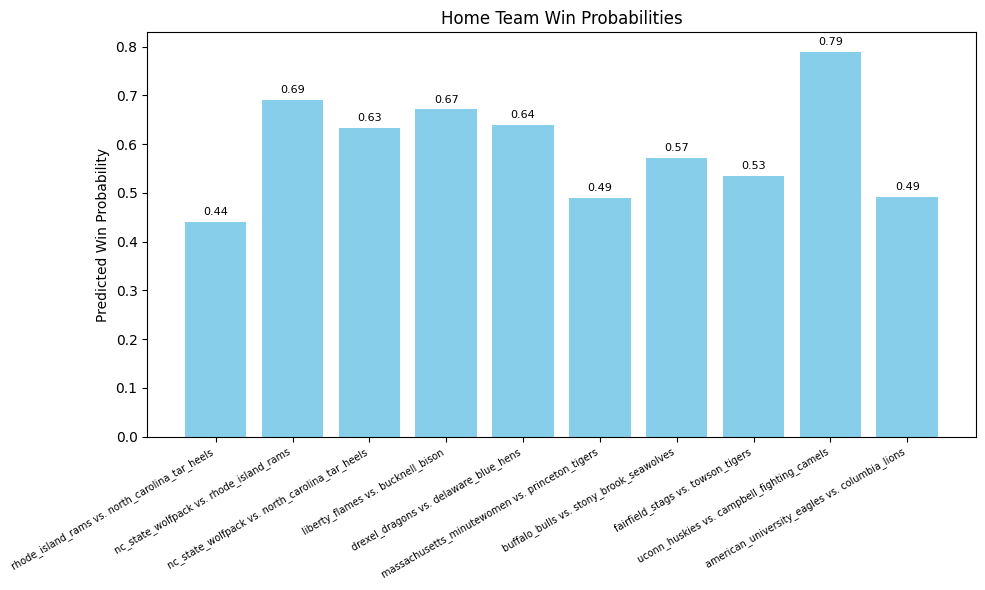

In [57]:
results_df = pd.DataFrame({
    "predicted_prob_model": [
        0.440387, 0.690749, 0.633938, 0.671101, 0.639433,
        0.488816, 0.572055, 0.534959, 0.789622, 0.492439
    ],
    "team_home": [
        "rhode_island_rams vs. north_carolina_tar_heels",
        "nc_state_wolfpack vs. rhode_island_rams",
        "nc_state_wolfpack vs. north_carolina_tar_heels",
        "liberty_flames vs. bucknell_bison",
        "drexel_dragons vs. delaware_blue_hens",
        "massachusetts_minutewomen vs. princeton_tigers",
        "buffalo_bulls vs. stony_brook_seawolves",
        "fairfield_stags vs. towson_tigers",
        "uconn_huskies vs. campbell_fighting_camels",
        "american_university_eagles vs. columbia_lions"
    ]
})

teams = results_df["team_home"]
probs = results_df["predicted_prob_model"]
plt.figure(figsize=(10, 6))
bars = plt.bar(teams, probs, color='skyblue')

# Add probability labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=8
    )
plt.xticks(rotation=30, ha='right', fontsize=7)  # Rotate x-axis labels for readability
plt.ylabel("Predicted Win Probability")
plt.title("Home Team Win Probabilities")

plt.tight_layout()
plt.show()


## Inside the model - first boosted tree

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


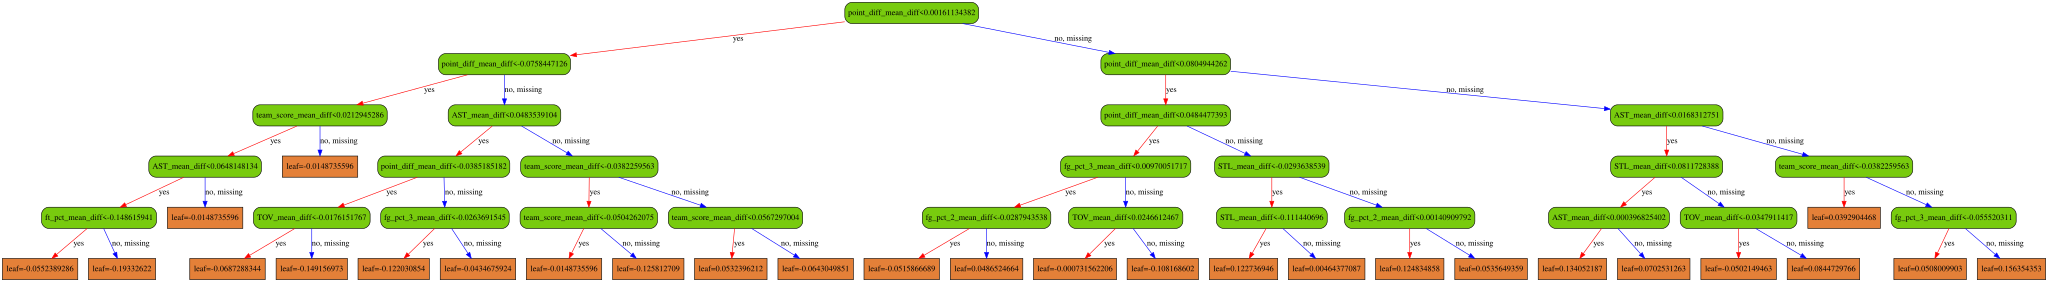

In [59]:
bst = model

node_params = {'shape': 'box',
              'style': 'filled, rounded',
              'fillcolor': '#78cbe'}

leaf_params = {'shape': 'box',
              'style': 'filled',
              'fillcolor': '#e48038'}

xgb.to_graphviz(model, num_trees=0, size="10,10",
               condition_node_params=node_params,
               leaf_node_params=leaf_params

               )